In [1]:
import micropip

In [2]:
for package in [
    "emfs:/drive/packages/pymatgen-2024.4.13-py3-none-any.whl",
    "emfs:/drive/packages/spglib-2.0.2-py3-none-any.whl",
    "emfs:/drive/packages/ruamel.yaml-0.17.32-py3-none-any.whl",
    "emfs:/drive/packages/pydantic_core-2.18.2-py3-none-any.whl",
    "emfs:/drive/packages/pydantic-2.7.1-py3-none-any.whl",
    "emfs:/drive/packages/torch-2.1.0a0-cp311-cp311-emscripten_3_1_45_wasm32.whl",
    "numpy",
    "scipy",
    "matplotlib",
    "sympy",
    "pydantic_settings",
    "xmltodict",
    "requests",
    "urllib3",
    "idna",
    "certifi",
    "scikit-learn",
    "tqdm",
    "jarvis-tools",
    "ase",
    "slakonet"
]:
    print(package)
    await micropip.install(package, deps=False)

emfs:/drive/packages/pymatgen-2024.4.13-py3-none-any.whl
emfs:/drive/packages/spglib-2.0.2-py3-none-any.whl
emfs:/drive/packages/ruamel.yaml-0.17.32-py3-none-any.whl
emfs:/drive/packages/pydantic_core-2.18.2-py3-none-any.whl
emfs:/drive/packages/pydantic-2.7.1-py3-none-any.whl
emfs:/drive/packages/torch-2.1.0a0-cp311-cp311-emscripten_3_1_45_wasm32.whl
numpy
scipy
matplotlib
sympy
pydantic_settings
xmltodict
requests
urllib3
idna
certifi
scikit-learn
tqdm
jarvis-tools
ase
slakonet


In [3]:
import torch
import numpy as np
from collections import namedtuple

# Define return types to mimic PyTorch's named tuples
EigRet = namedtuple('linalg_eig', ['eigenvalues', 'eigenvectors'])
EighRet = namedtuple('linalg_eigh', ['eigenvalues', 'eigenvectors'])

def _to_np(tensor):
    return tensor.detach().cpu().numpy()

def _to_torch(array, device, dtype=None):
    if dtype:
        return torch.tensor(array, device=device, dtype=dtype)
    return torch.tensor(array, device=device)

# --- Define the Patches ---

def patch_solve(A, B, *args, **kwargs):
    return _to_torch(np.linalg.solve(_to_np(A), _to_np(B)), A.device)

def patch_inv(A, *args, **kwargs):
    return _to_torch(np.linalg.inv(_to_np(A)), A.device)

def patch_det(A, *args, **kwargs):
    return _to_torch(np.linalg.det(_to_np(A)), A.device)

def patch_cholesky(A, *args, **kwargs):
    # NumPy's cholesky operates on the lower triangle by default, same as PyTorch
    return _to_torch(np.linalg.cholesky(_to_np(A)), A.device)

def patch_eig(A, *args, **kwargs):
    vals, vecs = np.linalg.eig(_to_np(A))
    return EigRet(_to_torch(vals, A.device), _to_torch(vecs, A.device))

def patch_eigh(A, UPLO='L', *args, **kwargs):
    vals, vecs = np.linalg.eigh(_to_np(A), UPLO=UPLO)
    return EighRet(_to_torch(vals, A.device), _to_torch(vecs, A.device))

# --- Apply the Patches to PyTorch ---

torch.linalg.solve = patch_solve
torch.linalg.inv = patch_inv
torch.inverse = patch_inv  # Alias
torch.linalg.det = patch_det
torch.det = patch_det      # Alias
torch.linalg.cholesky = patch_cholesky
torch.linalg.eig = patch_eig
torch.linalg.eigh = patch_eigh

# Fix numpy
def _tensor_array_compat(self, dtype=None):
    """Replacement for Tensor.__array__ in Pyodide where tensor.numpy() is unavailable."""
    arr = np.array(self.tolist())
    return arr.astype(dtype) if dtype is not None else arr
torch.Tensor.__array__ = _tensor_array_compat
torch.Tensor.numpy = lambda self: np.array(self.detach().tolist())


# Keep the SciPy LU patches we made earlier just in case
import scipy.linalg
LUFactorReturn = namedtuple('LUFactorReturn', ['LU', 'pivots'])

def patch_lu_factor(A, *args, **kwargs):
    A_np = _to_np(A)
    if A_np.ndim > 2:
        orig_shape = A_np.shape
        A_reshaped = A_np.reshape(-1, orig_shape[-2], orig_shape[-1])
        lu_list, piv_list = [], []
        for mat in A_reshaped:
            lu, piv = scipy.linalg.lu_factor(mat)
            lu_list.append(lu)
            piv_list.append(piv)
        LU_np = np.stack(lu_list).reshape(orig_shape)
        piv_np = np.stack(piv_list).reshape(orig_shape[:-2] + (-1,))
    else:
        LU_np, piv_np = scipy.linalg.lu_factor(A_np)
    return LUFactorReturn(_to_torch(LU_np, A.device, A.dtype), _to_torch(piv_np, A.device, torch.int32))

def patch_lu_solve(LU, pivots, B, *args, **kwargs):
    LU_np, piv_np, B_np = _to_np(LU), _to_np(pivots), _to_np(B)
    if LU_np.ndim > 2:
        orig_shape_B = B_np.shape
        LU_reshaped = LU_np.reshape(-1, LU_np.shape[-2], LU_np.shape[-1])
        piv_reshaped = piv_np.reshape(-1, piv_np.shape[-1])
        is_vector = (B_np.ndim == LU_np.ndim - 1)
        B_reshaped = B_np.reshape(-1, B_np.shape[-1], 1) if is_vector else B_np.reshape(-1, B_np.shape[-2], B_np.shape[-1])
        X_list = [scipy.linalg.lu_solve((lu, piv), b) for lu, piv, b in zip(LU_reshaped, piv_reshaped, B_reshaped)]
        X_np = np.stack(X_list).reshape(orig_shape_B)
    else:
        X_np = scipy.linalg.lu_solve((LU_np, piv_np), B_np)
    return _to_torch(X_np, B.device, B.dtype)

torch.linalg.lu_factor = patch_lu_factor
torch.linalg.lu_solve = patch_lu_solve

print("All major torch.linalg functions successfully patched to use NumPy/SciPy!")

All major torch.linalg functions successfully patched to use NumPy/SciPy!


In [4]:
from slakonet.optim import (
    MultiElementSkfParameterOptimizer,
    get_atoms,
    kpts_to_klines,
    default_model,
)
import torch
from slakonet.atoms import Geometry
from slakonet.main import generate_shell_dict_upto_Z65

model = default_model()

# Get structure (example with JARVIS ID)
atoms, opt_gap, mbj_gap = get_atoms("JVASP-1002")  
geometry = Geometry.from_ase_atoms([atoms.ase_converter()])
shell_dict = generate_shell_dict_upto_Z65()

/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/lib/python3.11/site-packages/slakonet/optim.py:3081: TqdmMonitorWarning: tqdm:disabling monitor support (monitor_interval = 0) due to:
can't start new thread
  progress_bar = tqdm(total=total_size_in_bytes, unit="iB", unit_scale=True)
100%|██████████| 183M/183M [00:01<00:00, 132MiB/s]  


Saved zip file: /home/pyodide/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.zip
Extracting model file...
Extracted model to: /home/pyodide/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
✅ Compact model loaded from: /home/pyodide/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
Total time: 32.26s
Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 40.8M/40.8M [00:00<00:00, 128MiB/s]


Loading the zipfile...
Loading completed.


In [5]:
import torch

# Your original waypoints (k_x, k_y, k_z, density)
waypoints = [
    [0.000, 0.000, 0.000, 10], # Gamma
    [0.500, 0.000, 0.500, 10], # X
    [0.500, 0.250, 0.750, 10], # W
    [0.375, 0.375, 0.750, 10], # K
    [0.000, 0.000, 0.000, 10], # Gamma
    [0.500, 0.500, 0.500, 10], # L
    [0.625, 0.250, 0.625, 10], # U
    [0.500, 0.250, 0.750, 10], # W
    [0.500, 0.500, 0.500, 10], # L
    [0.625, 0.250, 0.625, 10], # U
    [0.500, 0.000, 0.500, 10], # X
]

# Convert waypoints into 7-element segments: [start_k, end_k, N]
formatted_segments = []
for i in range(len(waypoints) - 1):
    start = waypoints[i][:3]      # Get x, y, z of current point
    end = waypoints[i+1][:3]      # Get x, y, z of next point
    num_points = waypoints[i+1][3] # Get the N value from the destination point
    
    formatted_segments.append(start + end + [num_points])

# slakonet expects (batch, num_segments, 7)
klines_tensor = torch.tensor([formatted_segments], dtype=torch.float32)

# Run the calculation
with torch.no_grad():
    properties, success = model.compute_multi_element_properties(
        geometry=geometry,
        shell_dict=shell_dict,
        klines=klines_tensor, 
        get_fermi=True,
    )

print(f"Calculation successful: {success}")

Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, but got: c10::complex<float> != c10::complex<double>, falling back to eig
Cholesky failed: expected m1 and m2 to have the same dtype, bu

In [6]:
# Access results using .item() to extract the float from the Tensor
print(f"Band gap: {properties['bandgap'].item():.3f} eV")

Band gap: 1.084 eV


In [7]:
print(f"Fermi energy: {properties['fermi_energy'].item():.3f} eV")

Fermi energy: -2.494 eV


In [8]:
# Plot band structure and DOS
eigenvalues = properties["eigenvalues"]
dos_values = properties['dos_values_tensor']
dos_energies = properties['dos_energy_grid_tensor']


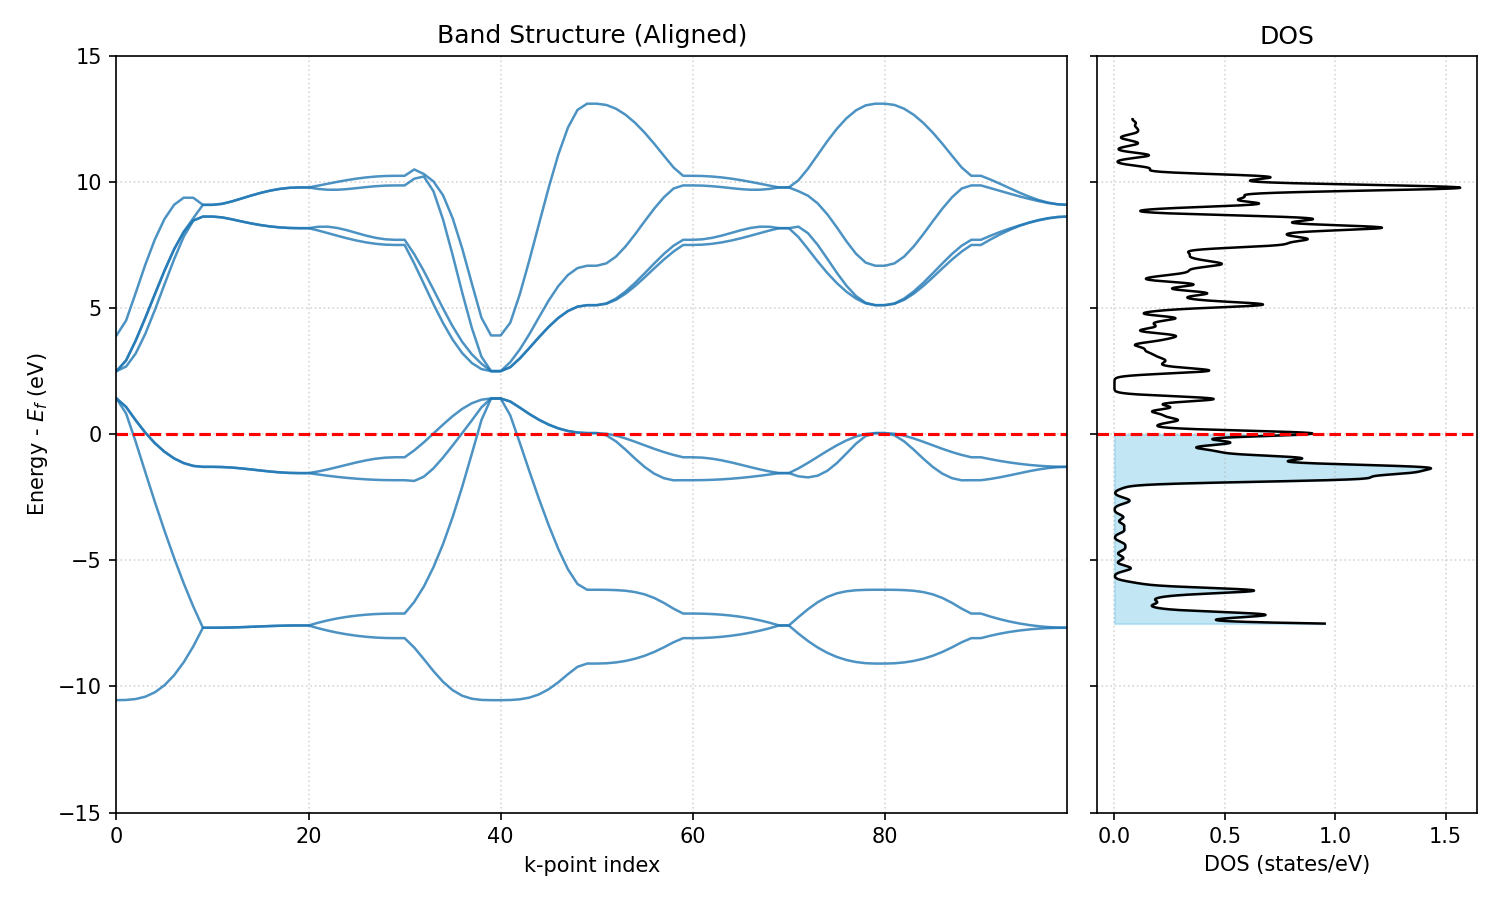

In [9]:
import matplotlib
matplotlib.use("Agg") 
import matplotlib.pyplot as plt
import numpy as np
import io
import base64

# 1. Extract and Clean Data
# Use .squeeze() but be careful with batch dimensions
raw_eigenvals = properties["eigenvalues"].detach().cpu().numpy()
if raw_eigenvals.ndim == 3:
    raw_eigenvals = raw_eigenvals[0] # Take first batch

# CRITICAL: Sort eigenvalues at each k-point to prevent "zig-zags" 
# between energy levels that swap indices
eigenvals = np.sort(raw_eigenvals, axis=1)

dos_vals = properties['dos_values_tensor'].detach().cpu().numpy()
dos_energies = properties['dos_energy_grid_tensor'].detach().cpu().numpy()
e_fermi = properties['fermi_energy'].item()

# Shift everything relative to Fermi Level (Standard convention)
eigenvals -= e_fermi
dos_energies -= e_fermi

# 2. Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), 
                               gridspec_kw={'width_ratios': [2.5, 1]}, sharey=True)

# ==========================================
# Plot 1: Band Structure
# ==========================================
num_kpoints = eigenvals.shape[0]
k_axis = np.arange(num_kpoints)

# Plot each band individually
for i in range(eigenvals.shape[1]):
    ax1.plot(k_axis, eigenvals[:, i], color='#1f77b4', linewidth=1.2, alpha=0.8)

# Add a horizontal line at the NEW Fermi Level (0 eV)
ax1.axhline(0, color='r', linestyle='--', label='Fermi Level', linewidth=1.5)

ax1.set_ylabel('Energy - $E_f$ (eV)')
ax1.set_xlabel('k-point index')
ax1.set_title('Band Structure (Aligned)')
ax1.set_xlim(0, num_kpoints - 1)
ax1.grid(True, linestyle=':', alpha=0.5)

# ==========================================
# Plot 2: Density of States (DOS)
# ==========================================
ax2.plot(dos_vals, dos_energies, color='k', linewidth=1.2)
ax2.axhline(0, color='r', linestyle='--')

# Fill valence states (below Fermi Level)
ax2.fill_betweenx(dos_energies, 0, dos_vals, where=(dos_energies <= 0), color='skyblue', alpha=0.5)

ax2.set_xlabel('DOS (states/eV)')
ax2.set_title('DOS')
ax2.grid(True, linestyle=':', alpha=0.5)

# Adjust y-limit to focus on the interesting region around the gap
ax1.set_ylim(-15, 15) 
ax2.set_ylim(-15, 15) 

plt.tight_layout()

# ==========================================
# Pyodide Export
# ==========================================
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
buf.seek(0)
plt.close(fig) 

img_base64 = base64.b64encode(buf.read()).decode('utf-8')
img_html = f'<img src="data:image/png;base64,{img_base64}" style="width:100%; max-width:800px;" />'

from IPython.display import display, HTML
display(HTML(img_html))